In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
from pathlib import Path

from jiflr import ROOT

plt.style.use('default')

# Load files

In [2]:
p = Path(
    "/Users/drotto/src/jiflr/data/external/JIRP_MASSBALANCE_2024/JIRP-Mass-Balance/glacier-mass-balance-code/data/Taku/Output/Output_Taku_Adjusted_Point_Balances.csv")
b_adjpt = pd.read_csv(p, parse_dates=['mass_maximum_date', 'mass_minimum_date'])

p = Path("/Users/drotto/src/jiflr/data/external/JIRP_MASSBALANCE_2024/JIRP-Mass-Balance/Raw Snowpit Data")
ps = sorted(list(p.glob('[0-9]*')))

ds = []
for p in ps:
    d = pd.read_excel(p)
    d = d[~d.map(lambda x: x in ['#REF!', '#VALUE!']).any(axis=1)]
    yr = int(p.name.split("_")[0])
    d['Year'] = yr
    ds.append(d)
b_raw = pd.concat(ds, ignore_index=True)    

print("b_raw number of sites: ", b_raw.Snowpit.nunique())
b_raw


/Users/drotto/micromamba/envs/jiflr/lib/python3.11/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


b_raw number of sites:  152


,Glacier,Snowpit,Easting(m),Northing(m),Elevation (m),Date,Snow Depth (cm),Adjusted S.W.E.(cm),Mean Snow Density(g/cm^3),Standard Deviation,Mean ablation Rate,Days till 8/10,Total Ablation(cm),Total Ablation S.W.E. (cm),Year,AdjSWE/Depth (includes ice lenses)
0,Taku Glacier,TKGSP4.10,545594,6500605,1100,1949-08-14 00:00:00,451,248.05,0.55,0,NaN,NaN,NaN,NaN,1949,NaN
1,Taku Glacier,TKGSP4,0,0,1082,1950-07-22 00:00:00,190,104.5,0.55,0,NaN,NaN,NaN,NaN,1950,NaN
2,Taku Glacier,TKGSP4,544299,6499596,1082,1951-06-07 00:00:00,340,187.0,0.55,0,NaN,NaN,NaN,NaN,1951,NaN
3,Taku Glacier,TKGSP4.10,0,0,1090,1952-08-23 00:00:00,155,85.25,0.55,0,NaN,NaN,NaN,NaN,1952,NaN
4,Taku Glacier,TKGSPD,0,0,600,1952-07-07 00:00:00,70,38.5,0.55,0,NaN,NaN,NaN,NaN,1952,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
753,Llwellyn Glacier,LLG1,0,0,0,00:00:00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN
754,Llwellyn Glacier,LLG2,0,0,0,00:00:00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN
755,Llwellyn Glacier,LLG3,0,0,0,00:00:00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN
756,Llwellyn Glacier,LLG4,0,0,0,00:00:00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN


# Clean data

In [3]:
numeric_cols = [col for col in b_raw.columns if col not in ['Glacier', 'Snowpit', 'Date']]
b_raw.loc[:, numeric_cols] = b_raw.loc[:, numeric_cols].apply(pd.to_numeric, errors='coerce', axis=1)
# mask = b_raw["Elevation (m)"].isin([np.nan, 0.0])
# b_raw = b_raw[~mask]
b_raw['Snowpit'] = b_raw["Snowpit"].str.replace('SP', '')  # make old pit names match current
b_raw['Snowpit'] = b_raw["Snowpit"].str.replace('(\.[0-9])*', '', regex=True)  # make old pit names match current
b_raw['Snowpit'] = b_raw["Snowpit"].str.replace('-|#', '', regex=True)  # make old pit names match current
print("b_raw number of sites: ", b_raw.Snowpit.nunique())
#b_raw = b_raw.loc[b_raw["Snowpit"].isin(b_adjpt['site_name'])]

# merge with processed point data
b_raw = b_raw.rename(columns={
    "Snowpit"                  : "site_name",
    " Snow Depth (cm)"         : "snow_depth_cm",
    "Adjusted S.W.E.(cm)"      : "adj_swe_cm",
    "Mean Snow Density(g/cm^3)": "mean_snow_density_gcm3",
})

b_raw number of sites:  93


In [4]:
b = b_adjpt.merge(b_raw, how='inner')
b = b.drop(columns=['Elevation (m)', "Mean ablation Rate", "Days till 8/10", "Total Ablation(cm)",
                    "Total Ablation S.W.E. (cm)", "AdjSWE/Depth (includes ice lenses)"])
b = b.rename(columns={
    "Date"              : "pit_date",
    "Standard Deviation": "snow_density_std",
})
b['pit_date'] = pd.to_datetime(b['pit_date'], errors='coerce')
b['pit_doy'] = b['pit_date'].dt.dayofyear

# filter to midsummer days
b = b.loc[(b['pit_doy'] > 120) & (b['pit_doy'] < 250)]

# filter bad data
b = b.loc[b['mean_snow_density_gcm3'] > 0.1]

print("b number of sites: ", b.site_name.nunique())
b

b number of sites:  31


,Year,site_name,elevation,bw,bs,ba,mass_maximum_date,mass_minimum_date,Lapse_Rate,Time_System,...,Integration_Surface,Glacier,Easting(m),Northing(m),pit_date,snow_depth_cm,adj_swe_cm,mean_snow_density_gcm3,snow_density_std,pit_doy
0,1995,TKG5,991.0,2.14,-3.52,-1.38,1995-04-18,1995-10-06,-5,Fixed_Date_Stratigraphic,...,Conventional,Taku Glacier,547697.0,6496299.0,1995-07-23,120.0,74.134,0.613,0.024042,204.0
1,1995,DG1,1023.0,2.25,-3.32,-1.06,1995-04-18,1995-10-06,-5,Fixed_Date_Stratigraphic,...,Conventional,Taku Glacier,550823.0,6498009.0,1995-07-28,130.0,73.0755,0.5595,0.046314,209.0
2,1995,SWB2,1064.0,2.41,-3.04,-0.63,1995-04-18,1995-10-06,-5,Fixed_Date_Stratigraphic,...,Conventional,Taku Glacier,544086.0,6495359.0,1995-07-22,155.0,94.284,0.586,0.024576,203.0
3,1995,TKG4,1110.0,2.57,-2.58,-0.01,1995-04-18,1995-10-06,-5,Fixed_Date_Stratigraphic,...,Conventional,Taku Glacier,544650.93,6499406.45,1995-07-23,196.0,113.941333,0.581333,0.021572,204.0
4,1995,TKG2,1182.0,2.60,-2.43,0.17,1995-04-18,1995-10-06,-5,Fixed_Date_Stratigraphic,...,Conventional,Taku Glacier,539081.0,6504548.0,1995-07-24,210.0,122.856,0.582,0.024055,205.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321,2021,MG2,1755.0,3.69,-0.99,2.69,2021-05-15,2021-09-26,-5,Fixed_Date_Stratigraphic,...,Conventional,Taku Glacier,546507.0,6319112.0,2021-07-27,595.0,333.9,0.546316,0.040117,208.0
322,2021,MG5,1827.0,2.90,-0.89,2.01,2021-05-15,2021-09-26,-5,Fixed_Date_Stratigraphic,...,Conventional,Taku Glacier,550105.0,6516625.0,2021-07-26,490.0,275.951915,0.548085,0.040035,207.0
323,2022,TKG5,959.0,3.35,-2.78,0.58,2022-05-10,2022-10-03,-5,Fixed_Date_Stratigraphic,...,Conventional,Taku Glacier,647654.0,6496242.0,2022-06-30,400.0,246.583923,0.605795,0.047281,181.0
327,2022,C161,1482.0,3.61,-1.85,1.76,2022-05-10,2022-10-03,-5,Fixed_Date_Stratigraphic,...,Conventional,Taku Glacier,533748.0,6499349.0,2022-05-07,530.0,305.879048,0.56381,0.031309,127.0


# Plot results

In [5]:
b.site_name.nunique()

31

# Estimate post-pit melt

The following plots show...

Text(0.5, 1.0, 'Remaining melt by site (1995-2022), $\\rho_{ba}$ = 0.917')

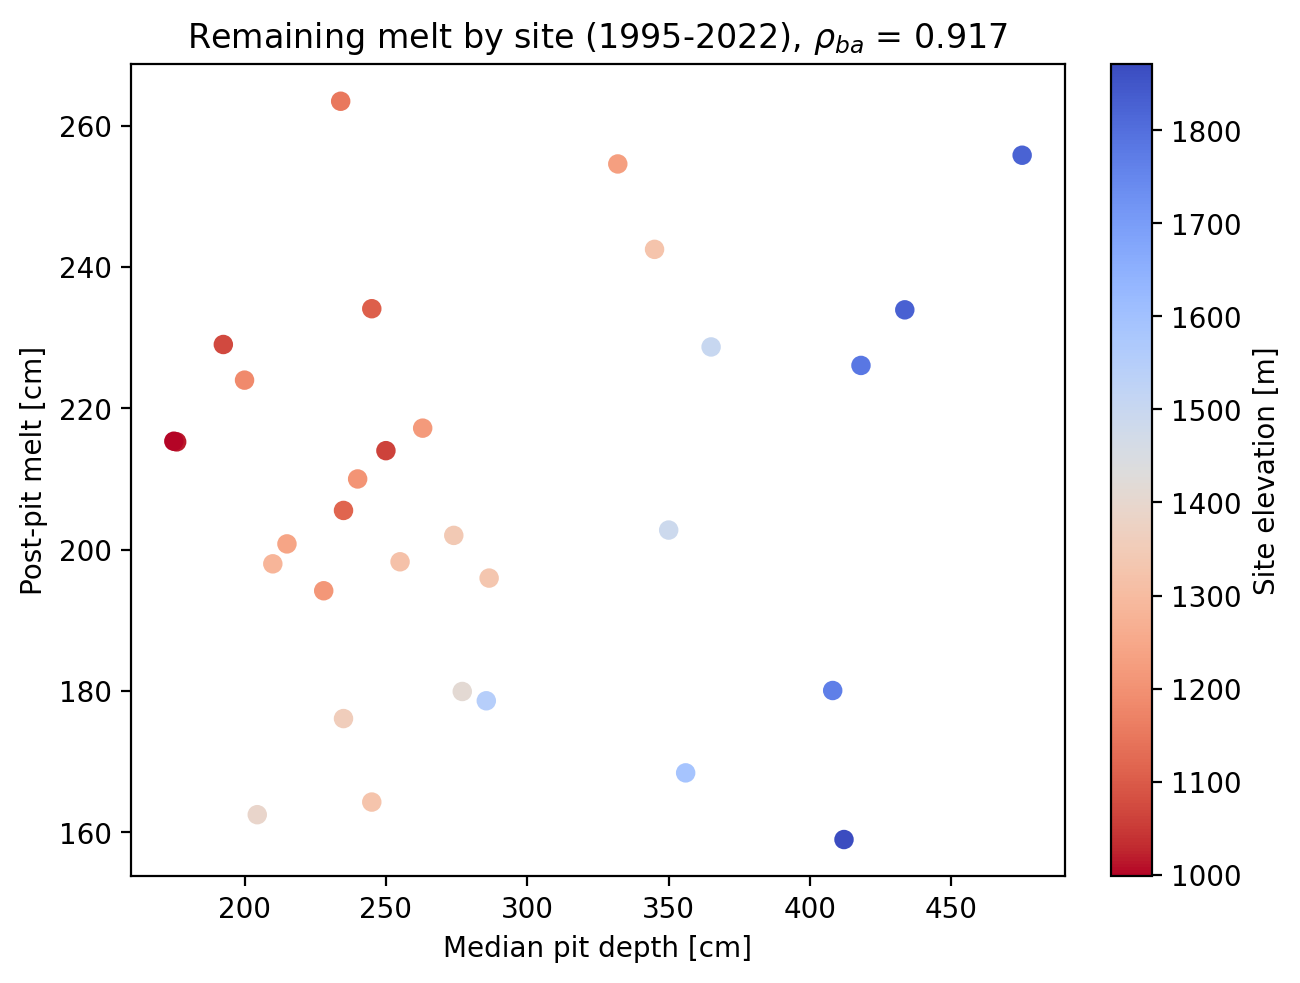

In [6]:
# median grouped by site
b_med = b.groupby(['site_name'])[['snow_depth_cm', 'pit_date', 'elevation', 'bw', 'ba', 'bs', 'pit_doy', 'mean_snow_density_gcm3', 'adj_swe_cm']].median().reset_index()


b_med['melt_remaining'] = b_med.snow_depth_cm - b_med.ba * 100 / 0.917  # assuming ice densityb
fig, ax = plt.subplots(dpi=200, layout="constrained")
scat = ax.scatter(b_med.snow_depth_cm, b_med["melt_remaining"], c=b_med.elevation, cmap='coolwarm_r')
fig.colorbar(scat, label='Site elevation [m]')
ax.set_xlabel("Median pit depth [cm]")
ax.set_ylabel("Post-pit melt [cm]")
ax.set_title(r"Remaining melt by site (1995-2022), $\rho_{ba}$ = 0.917")

Text(0.5, 1.0, 'Remaining melt by site (1995-2022), $\\rho_{ba}$ = 0.700')

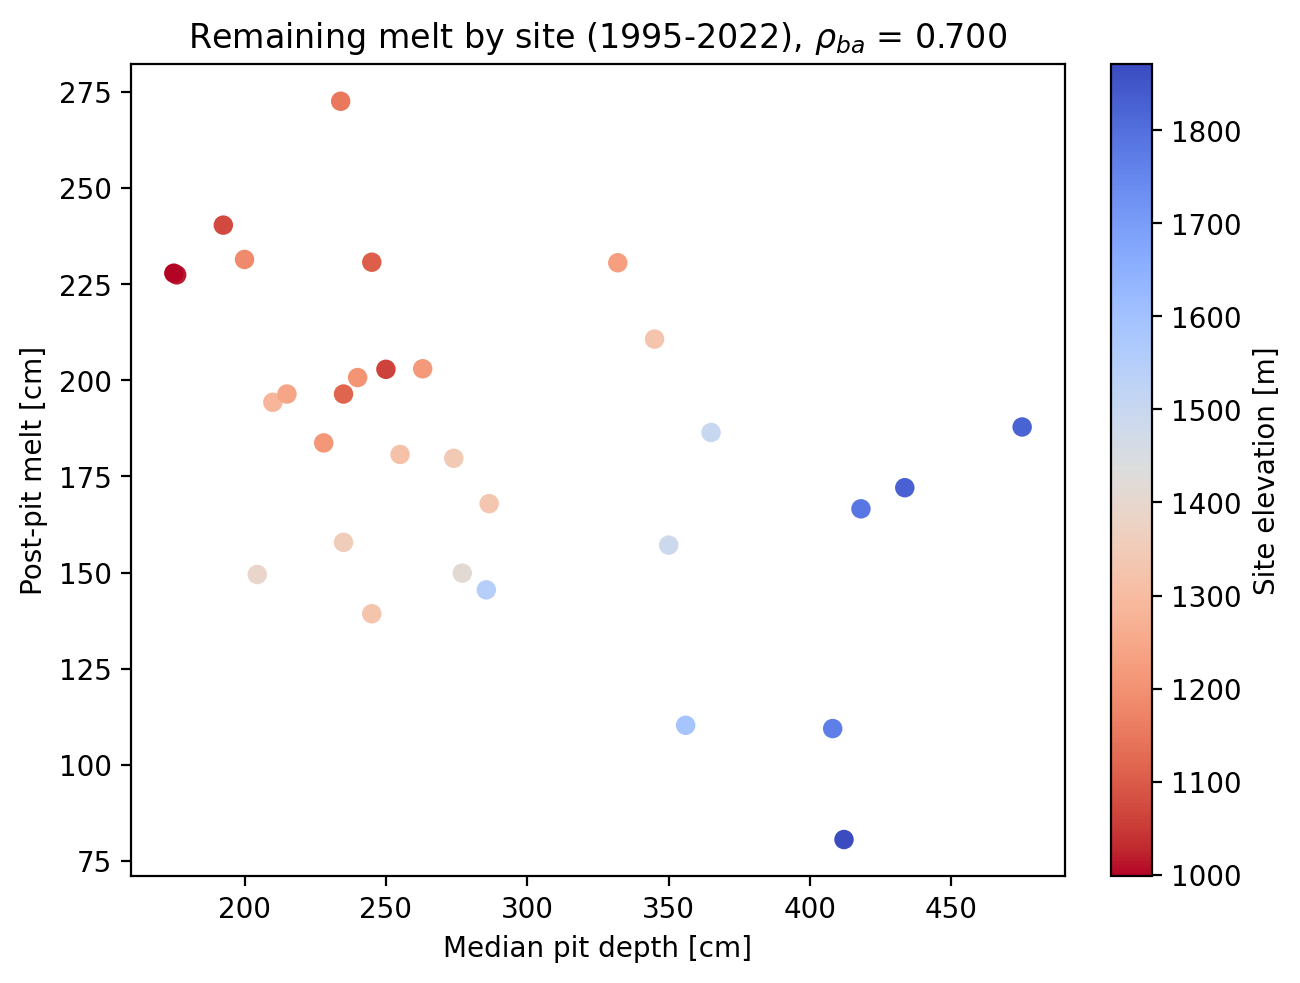

In [7]:
# median grouped by site
b_med = b.groupby(['site_name'])[['snow_depth_cm', 'pit_date', 'elevation', 'bw', 'ba', 'bs', 'pit_doy', 'mean_snow_density_gcm3']].median().reset_index()

b_med['melt_remaining'] = b_med.snow_depth_cm - b_med.ba * 100 / 0.700  # assuming firn density
fig, ax = plt.subplots(dpi=200, layout="constrained")
scat = ax.scatter(b_med.snow_depth_cm, b_med["melt_remaining"], c=b_med.elevation, cmap='coolwarm_r')
fig.colorbar(scat, label='Site elevation [m]')
ax.set_xlabel("Median pit depth [cm]")
ax.set_ylabel("Post-pit melt [cm]")
ax.set_title(r"Remaining melt by site (1995-2022), $\rho_{ba}$ = 0.700")

Text(0.5, 1.0, 'Remaining melt by site (1995-2022), $\\rho_{ba}$ = site median snow density')

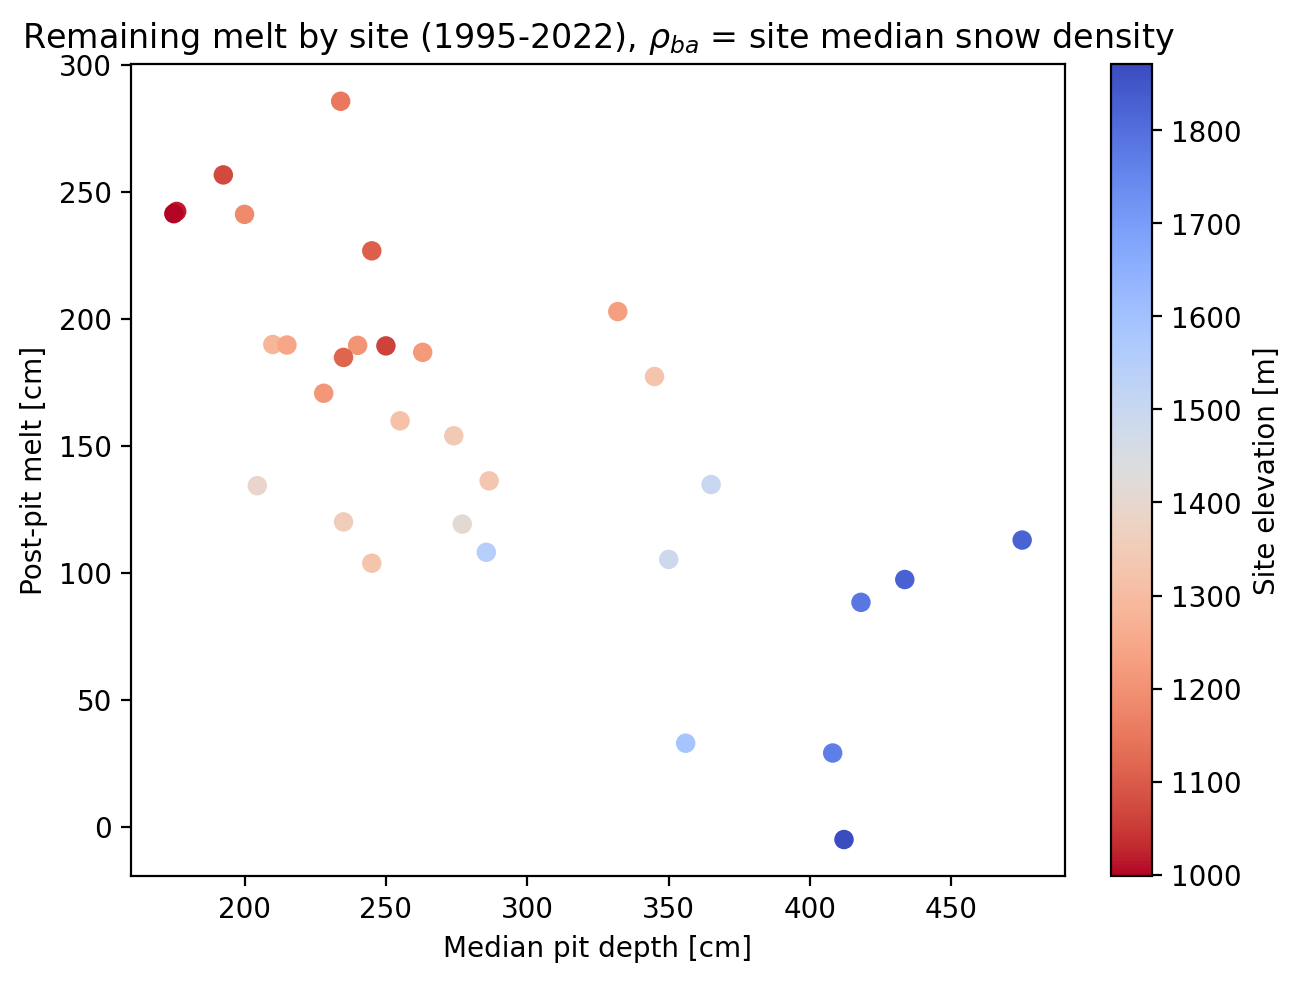

In [8]:
# median grouped by site
b_med = b.groupby(['site_name'])[['snow_depth_cm', 'pit_date', 'elevation', 'bw', 'ba', 'bs', 'pit_doy', 'mean_snow_density_gcm3']].median().reset_index()

b_med['melt_remaining'] = b_med.snow_depth_cm - b_med.ba * 100 / b_med.mean_snow_density_gcm3  # assuming snow density
fig, ax = plt.subplots(dpi=200, layout="constrained")
scat = ax.scatter(b_med.snow_depth_cm, b_med["melt_remaining"], c=b_med.elevation, cmap='coolwarm_r')
fig.colorbar(scat, label='Site elevation [m]')
ax.set_xlabel("Median pit depth [cm]")
ax.set_ylabel("Post-pit melt [cm]")
ax.set_title(r"Remaining melt by site (1995-2022), $\rho_{ba}$ = site median snow density")

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_47940/1976586716.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(index)


Text(0.5, 1.0, 'Melt remaining by site (1995-2022)')

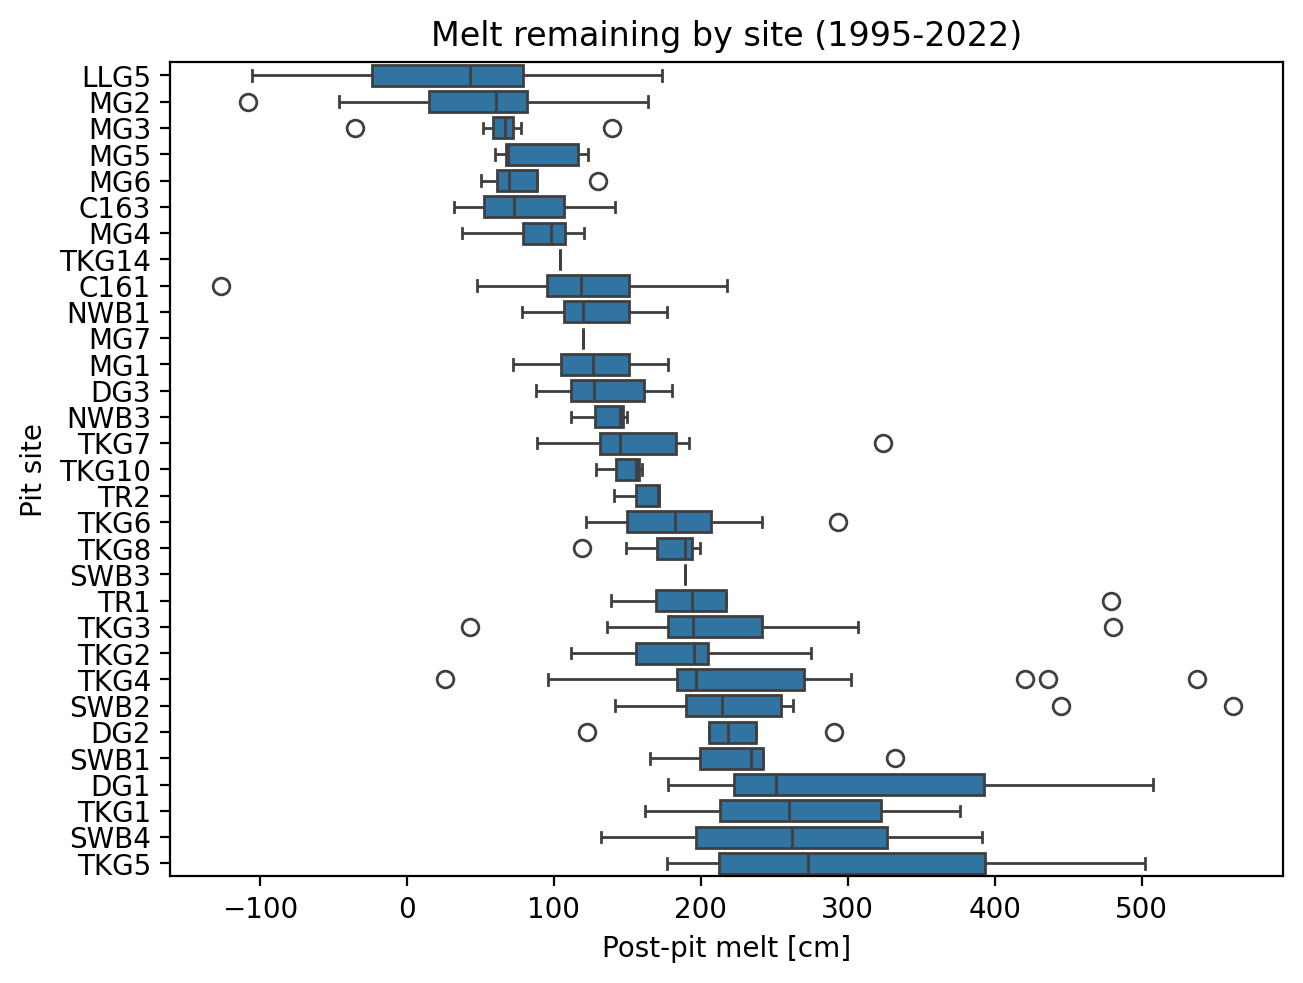

In [9]:
# calculate melt remaining for each record
b['melt_remaining_cm'] = b.snow_depth_cm - b.ba * 100 / b.mean_snow_density_gcm3

index = b.groupby('site_name')['melt_remaining_cm'].median().sort_values().index
fig, ax = plt.subplots(dpi=200, layout="constrained")
sns.boxplot(x=b.melt_remaining_cm, y=b.site_name, ax=ax, orient='y', order=index)
ax.set_yticklabels(index)
ax.set_ylabel("Pit site")
ax.set_xlabel("Post-pit melt [cm]")
ax.set_title("Melt remaining by site (1995-2022)")

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_47940/2361488346.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(index)


Text(0.5, 1.0, 'Melt remaining by site (1995-2022)')

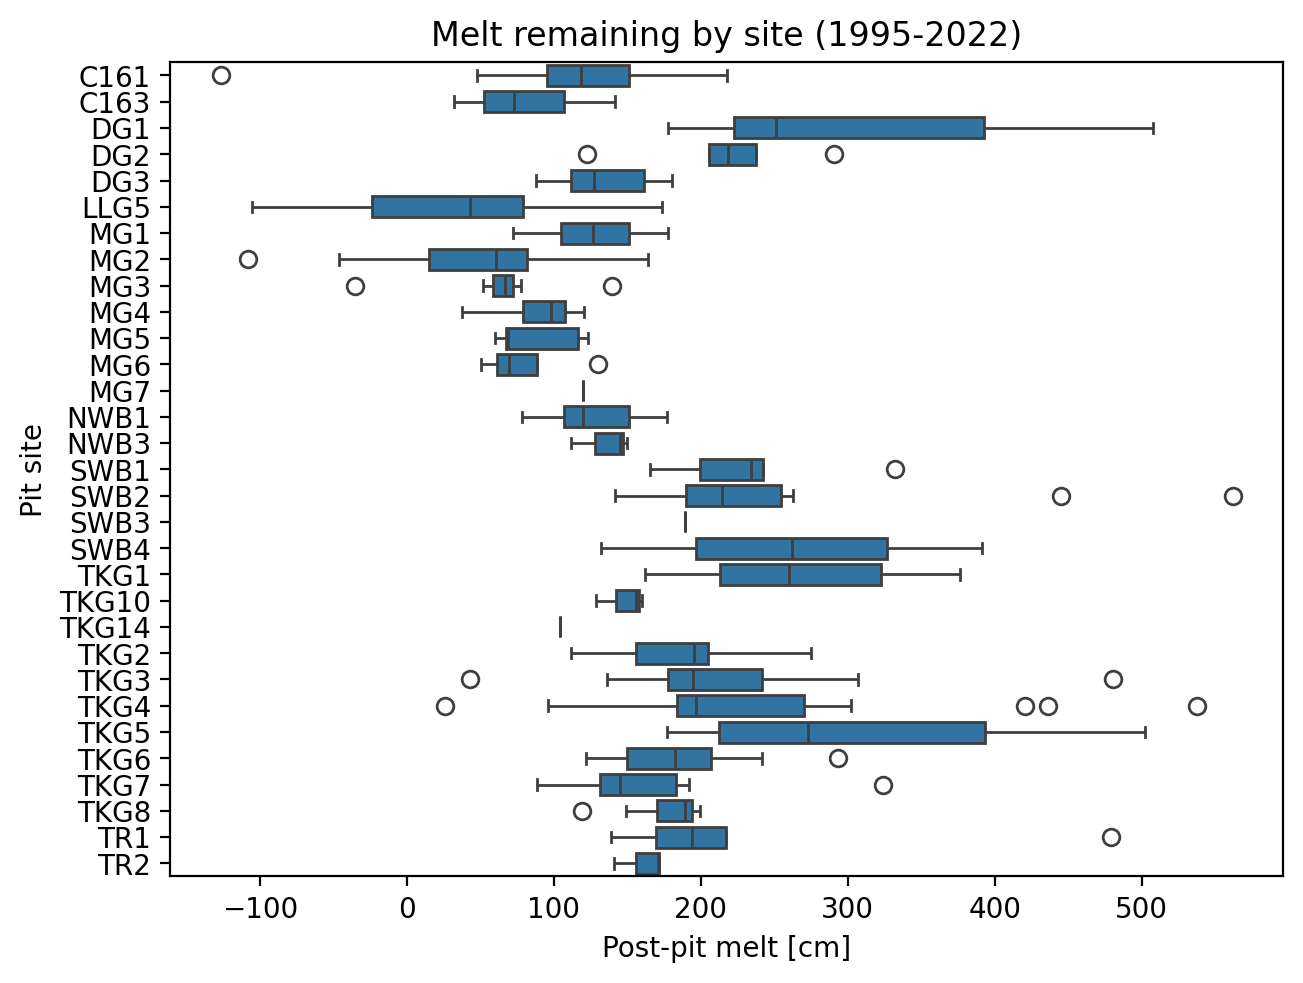

In [10]:
index = b.sort_values(by='site_name').groupby('site_name')['melt_remaining_cm'].median().index
fig, ax = plt.subplots(dpi=200, layout="constrained")
sns.boxplot(x=b.melt_remaining_cm, y=b.site_name, ax=ax, orient='y', order=index)
ax.set_yticklabels(index)
ax.set_ylabel("Pit site")
ax.set_xlabel("Post-pit melt [cm]")
ax.set_title("Melt remaining by site (1995-2022)")

In [11]:
b_med

,site_name,snow_depth_cm,pit_date,elevation,bw,ba,bs,pit_doy,mean_snow_density_gcm3,melt_remaining
0,C161,350.0,2009-07-29 00:00:00,1488.0,2.820,1.350,-1.550,206.0,0.551733,105.316578
1,C163,356.0,2015-07-23 00:00:00,1591.0,2.980,1.720,-1.230,204.0,0.532424,32.949345
2,DG1,176.0,2008-07-25 00:00:00,1016.0,2.110,-0.360,-2.550,201.0,0.542667,242.339066
3,DG2,200.0,2014-07-20 00:00:00,1184.0,2.370,-0.220,-2.320,201.0,0.53425,241.179223
4,DG3,286.5,2012-01-25 00:00:00,1329.0,2.780,0.830,-1.920,210.0,0.552424,136.25303
5,LLG5,412.0,2011-07-30 00:00:00,1871.0,2.370,2.320,-0.370,216.0,0.556386,-4.97673
6,MG1,204.5,2009-01-24 12:00:00,1393.0,2.195,0.385,-1.730,210.5,0.548837,134.351687
7,MG2,408.0,2011-01-30 00:00:00,1768.0,2.780,2.090,-0.795,214.5,0.551586,29.092305
8,MG3,418.0,2015-08-02 00:00:00,1785.0,2.610,1.760,-0.870,214.0,0.534,88.411985
9,MG4,285.5,2015-01-30 00:00:00,1549.5,2.515,0.980,-1.535,212.5,0.552499,108.124223


/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_47940/2753939619.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(index)


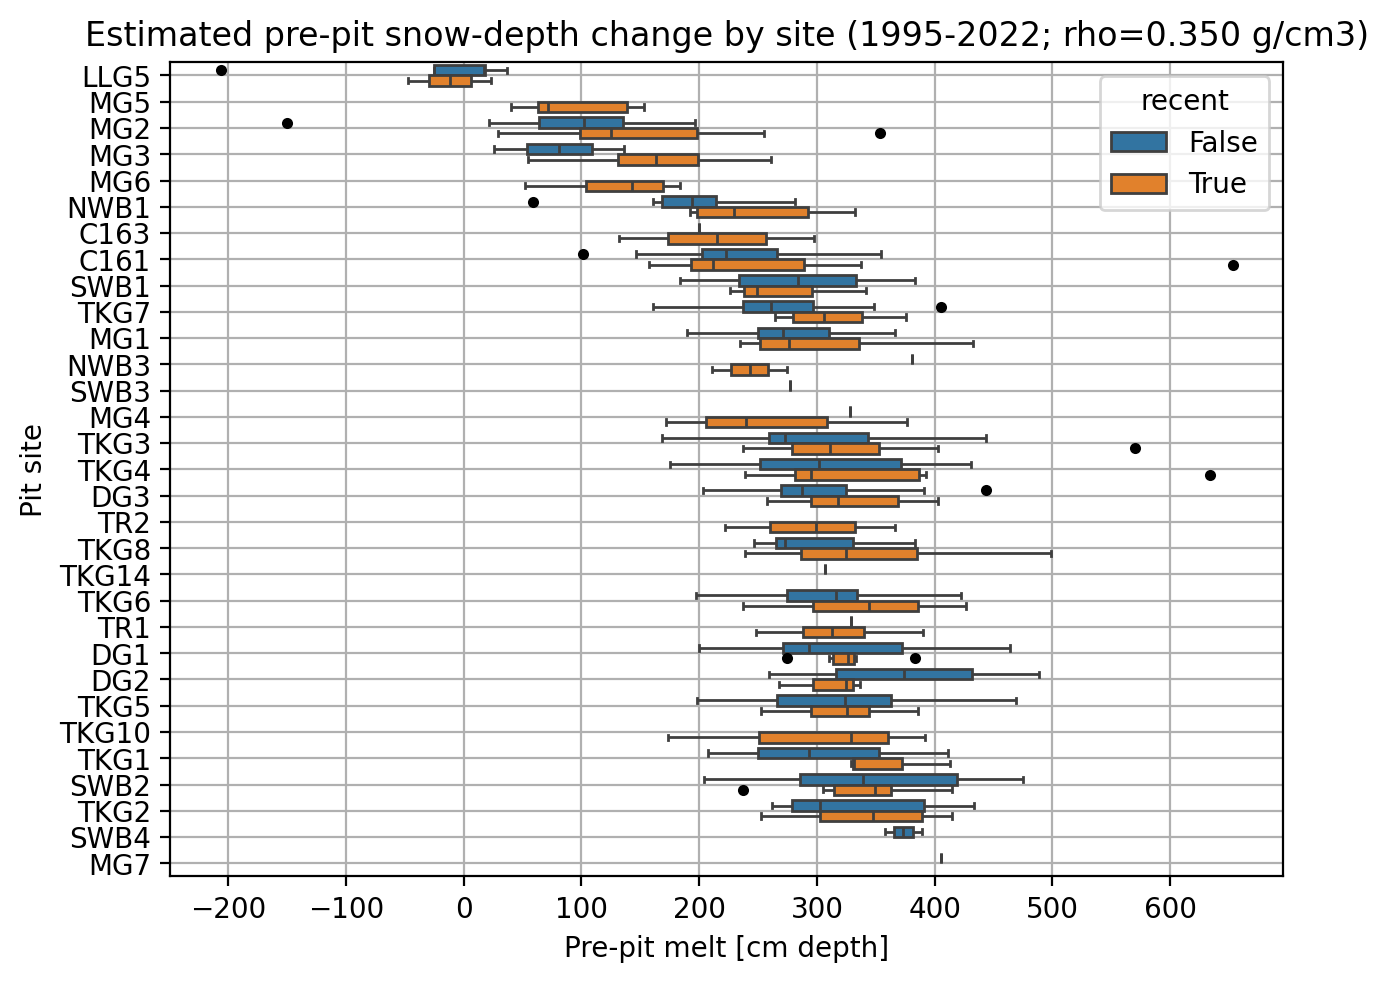

In [43]:
# melt already occurred
b['recent'] = b.Year > 2012
b['pre_pit_melt_cm'] = ((b.bw * 100) - b.adj_swe_cm) / 0.350  # 0.400 g/cm3

index = b.groupby('site_name')['pre_pit_melt_cm'].median().sort_values().index
fig, ax = plt.subplots(dpi=200, layout="constrained")
sns.boxplot(
    x=b.pre_pit_melt_cm,
    y=b.site_name,
    ax=ax,
    orient='y',
    order=index,
    hue=b.recent,
    flierprops={"markerfacecolor": "auto", "markeredgecolor": "none", "markersize":4}
    )
ax.set_yticklabels(index)
ax.set_ylabel("Pit site")
ax.set_xlabel("Pre-pit melt [cm depth]")
ax.set_title("Estimated pre-pit snow-depth change by site (1995-2022; rho=0.350 g/cm3)")
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(100))
ax.grid()